Predecir niveles de ruido cerca de aeropuerto.
Evaluar impacto acústico en zonas cercanas.
Datos de Dirección General de Aeronáutica Civil (DGAC)

Preguntas clave:
- ¿Qué factores influyen más en el ruido?
- ¿Hay diferencias según la aerolínea, hora o tipo de avión?
- ¿Por qué los sensores registran más ruido en las noches?


Diccionario de Variables
- NMT : Noise Monitoring Terminal: código del punto o estación de monitoreo de ruido.
- TLASmax : Timestamp de LASmax: fecha y hora de medición del nivel máximo de ruido.
- LASmax : Nivel máximo instantáneo de presión sonora ponderado A (dBA). Representa el mayor pico de ruido registrado durante el paso de una aeronave.
- SEL : Sound Exposure Level (dBA): Nivel de exposición sonora total de un evento de ruido, considerando duración y energía.
- Leq : Nivel equivalente (dBA): nivel continuo de presión sonora con la misma energía que el ruido fluctuante durante un período.
- LAZ : Nivel de ruido ponderado A con corrección de altitud o distancia (dBA). Es menos común, pero puede ser una medida ajustada.
- EPNL : Effective Perceived Noise Level (dB EPNL): Nivel de ruido percibido ajustado por la duración y características de la aeronave, usado en certificación aeronáutica.
- Temperature [°C] : Temperatura ambiental en grados Celsius. Puede influir en la propagación del sonido.
- A/D : Arrival / Departure: indica si el vuelo está aterrizando o despegando.
- Runway : Pista utilizada por la aeronave.
- Flight : Número de vuelo de la aeronave.
- Airline : Código IATA o ICAO de la aerolínea (ej: LAN, SKY).
- Airline (Name) : Nombre completo de la aerolínea.
- From/To : Ciudad o aeropuerto de origen o destino. Depende si es llegada o salida.
- Callsign : Identificador de radio usado por la aeronave.
- Aircraft Type : Tipo de aeronave.



EDA

In [ ]:
#descargar datos
import pandas as pd
df1 = pd.read_excel('../data/raw/NOISE TMR1.xlsx', skiprows=3)
df2 = pd.read_excel('../data/raw/NOISE TMR2.xlsx', skiprows=3)
df3 = pd.read_excel('../data/raw/NOISE TMR3.xlsx', skiprows=3)

#unir los tres dataframes
df = pd.concat([df1, df2, df3], ignore_index=True)
df

#Cambiar medicion a traves de funcion
#DGAC // aeropuertos << ruido amb << informe anual 2024

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/NOISE TMR1.xlsx'

In [ ]:
#borrar primera fila
df = df.drop(index=0)

In [ ]:
#tratar fecha
df['TLASmax'] = pd.to_datetime(df['TLASmax'], format='%d/%m/%Y %H:%M:%S')
df['Date'] = df['TLASmax'].dt.date
df['Hour'] = df['TLASmax'].dt.hour
df['DayOfWeek'] = df['TLASmax'].dt.day_name()

In [ ]:
#Tratamiento de duplicados
sum_dupli = df.duplicated().sum()
print(f'Se encontraron {sum_dupli} filas duplicadas')

Se encontraron 1 filas duplicadas


In [ ]:
df = df.drop_duplicates()

In [ ]:
#porcentaje de nulos de las columnas
def porcentaje_nulos(df):
    return df.isnull().sum() * 100 / len(df)
porcentaje_nulos(df)

NMT                  0.000352
TLASmax              0.000352
LASmax               0.000352
SEL                  0.000352
Leq                  0.000352
LAZ                  0.000352
EPNL                 1.071366
Temperature [°C]     0.211389
A/D                 45.474306
Runway              45.756041
Flight              45.474306
Airline             45.474306
Airline (Name)      54.851043
From/To             45.474306
Callsign            45.474306
Aircraft Type       45.474306
Date                 0.000352
Hour                 0.000352
DayOfWeek            0.000352
dtype: float64

In [ ]:
#buscando otro tratamiento de nulos
df2 = df.copy()
#Eliminar todos los nulos
df2 = df2.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126490 entries, 1 to 284311
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   NMT               126490 non-null  object        
 1   TLASmax           126490 non-null  datetime64[ns]
 2   LASmax            126490 non-null  float64       
 3   SEL               126490 non-null  float64       
 4   Leq               126490 non-null  float64       
 5   LAZ               126490 non-null  float64       
 6   EPNL              126490 non-null  float64       
 7   Temperature [°C]  126490 non-null  float64       
 8   A/D               126490 non-null  object        
 9   Runway            126490 non-null  object        
 10  Flight            126490 non-null  object        
 11  Airline           126490 non-null  object        
 12  Airline (Name)    126490 non-null  object        
 13  From/To           126490 non-null  object        
 14  Callsign 

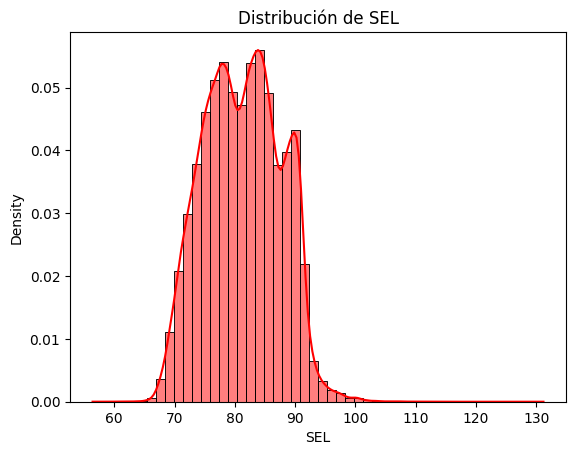

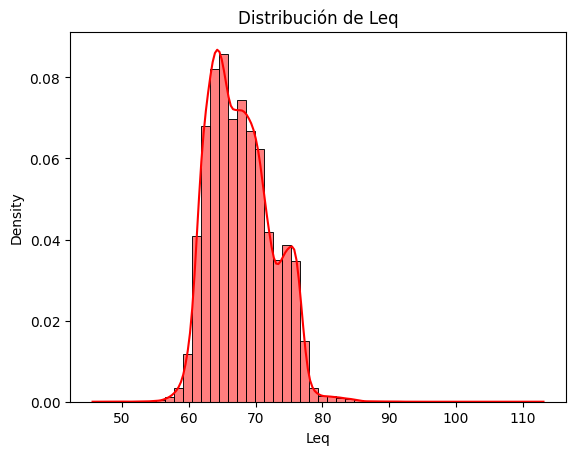

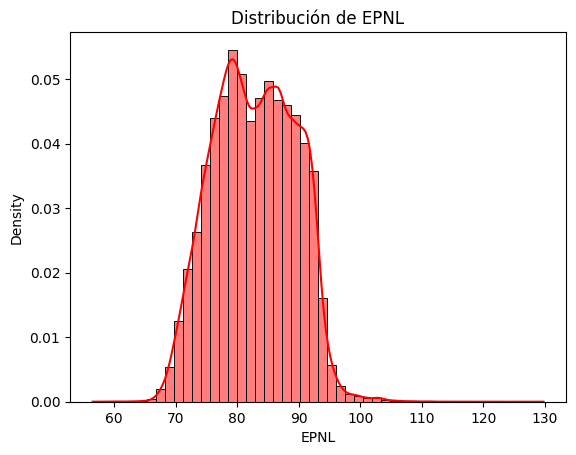

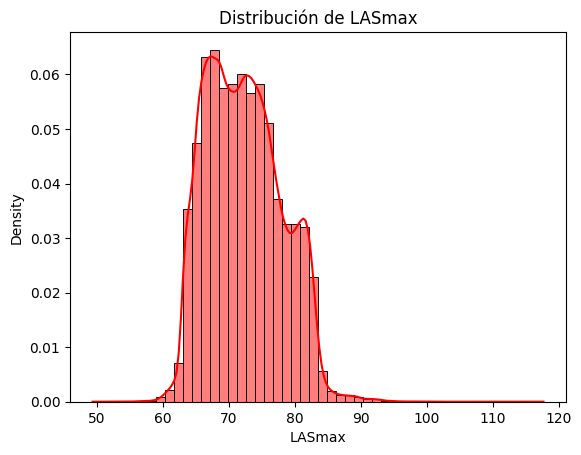

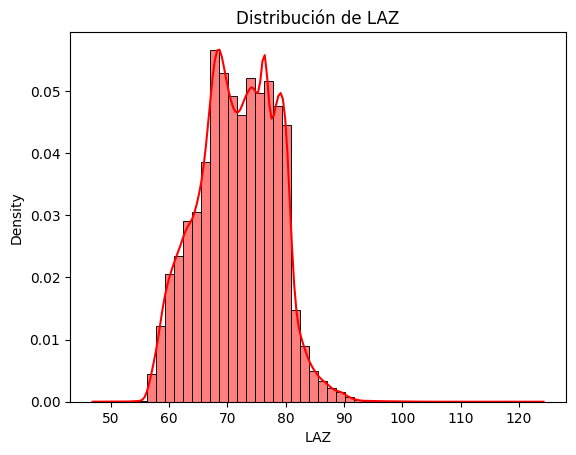

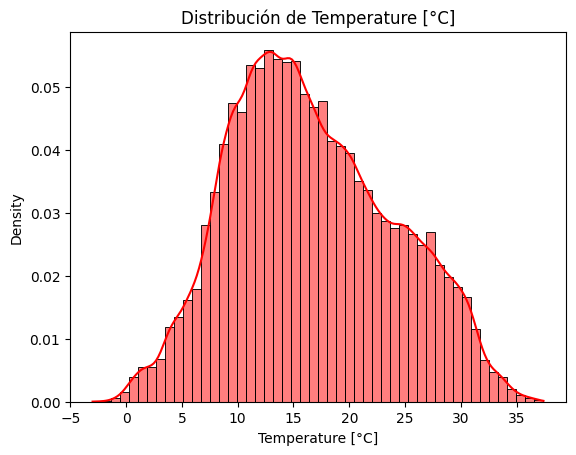

In [ ]:

for col in ['SEL', 'Leq', 'EPNL', 'LASmax', 'LAZ', 'Temperature [°C]']:
    sns.histplot(df2[col], kde=True, bins=50, color='red', stat='density')
    plt.title(f'Distribución de {col}')
    plt.show()

In [ ]:
df2.corr(numeric_only=True)['SEL'].sort_values(ascending=False)

SEL                 1.000000
LAZ                 0.969478
EPNL                0.964666
LASmax              0.867447
Leq                 0.843432
Hour               -0.139108
Temperature [°C]   -0.199498
Name: SEL, dtype: float64

<Axes: >

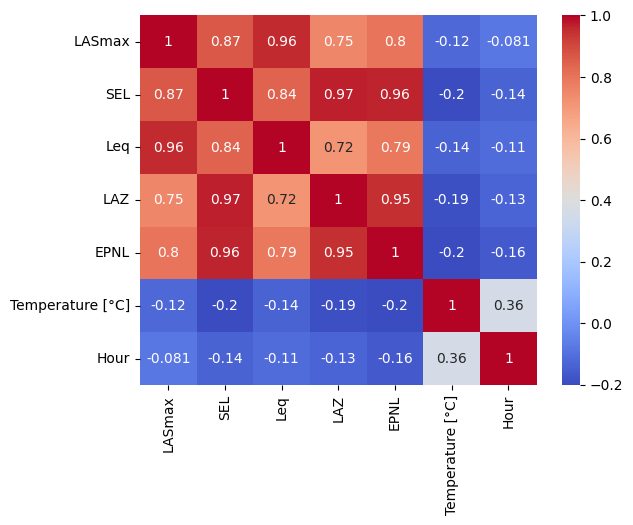

In [ ]:
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap='coolwarm')

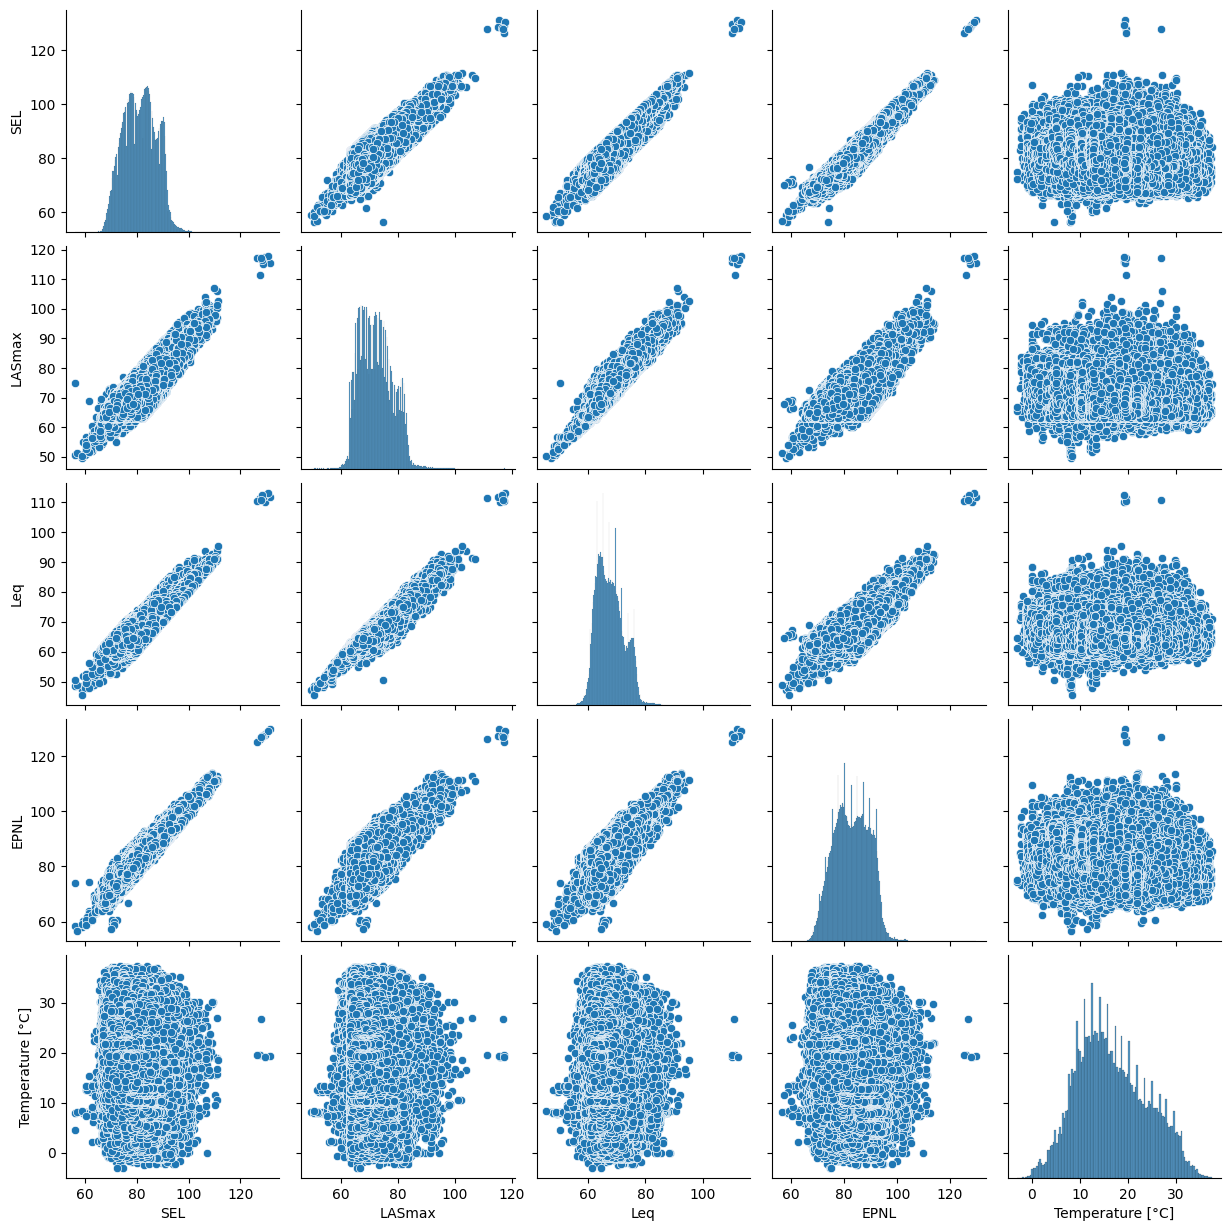

In [ ]:
sns.pairplot(df2[['SEL', 'LASmax', 'Leq', 'EPNL', 'Temperature [°C]']])
plt.show()

In [ ]:
#Comparar día vs noche
df1["is_night"] = df1["Hour"].apply(lambda x: x < 7 or x > 22) # ejemplo
df1.groupby("is_night")["SEL"].describe()


,count,mean,std,min,25%,50%,75%,max
is_night,,,,,,,,
False,211040.0,81.199590,6.27255,56.4,76.3,81.2,85.8,131.2
True,73269.0,81.458707,6.41792,56.8,76.4,81.7,86.5,107.3


In [ ]:
#Analizar por sensor (NMT)
df1.groupby(["NMT", "is_night"])["SEL"].mean().unstack()

is_night,False,True
NMT,,
MP01,79.613780,79.064949
MP02,84.327467,85.604133
MP03,80.098318,79.671261


Observación:
- El sensor MP02 muestra un leve aumento de ruido en las noches.


<Axes: xlabel='Temperature [°C]', ylabel='SEL'>

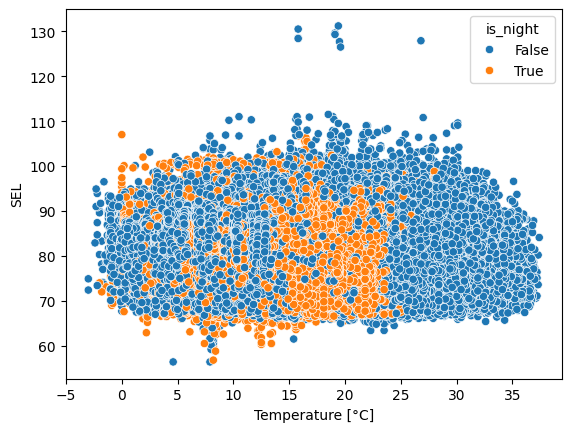

In [ ]:
#Analizar influencia de temperatura
sns.scatterplot(data=df1, x="Temperature [°C]", y="SEL", hue="is_night")

Observación:
- Los niveles de SEL varían entre 60 dB y 130 dB, con concentraciones notables en el rango de 12 a 25 °C.
- En temperaturas extremas (>30 °C o <5 °C), el SEL no supera los 100 dB, pero esto podría deberse a menor actividad.

En general, no se aprecia una tendencia clara, quizas se deba a falta de variables como humedad y velocidad del viento.

In [ ]:
#Un t-test entre SEL en día y noche para ver si la diferencia es estadísticamente significativa.
from scipy import stats
day_sel = df1[df1["is_night"] == False]["SEL"]
night_sel = df1[df1["is_night"] == True]["SEL"]
t_stat, p_value = stats.ttest_ind(day_sel, night_sel)
print(f"T-statistic: {t_stat}, P-value: {p_value}")
#Si el p-value es menor a 0.05, se rechaza la hipótesis nula de que no hay diferencia entre los dos grupos.

T-statistic: -9.576159323502175, P-value: 1.0148455606778733e-21


In [ ]:
import numpy as np
pooled_std = np.sqrt(((len(day_sel)-1)*day_sel.std()**2 + (len(night_sel)-1)*night_sel.std()**2) / (len(day_sel) + len(night_sel) - 2))
cohens_d = (night_sel.mean() - day_sel.mean()) / pooled_std
print(f"Cohen's d: {cohens_d}")
print(f"Media SEL día: {day_sel.mean():.2f}, noche: {night_sel.mean():.2f}")

Cohen's d: 0.04106238264912213
Media SEL día: 81.20, noche: 81.46


Observación:
- Diferencia de medias (noche - día): 0.26 dB  
- Tamaño del efecto (Cohen's d): 0.041 (efecto mínimo)  
Interpretación: Aunque estadísticamente la diferencia es significativa, no tiene relevancia práctica.  

In [ ]:
df1[df1["is_night"] == True]["Aircraft Type"].value_counts().head(10)

Aircraft Type
Desconocido    32425
A321            8095
A320            7773
A20N            6013
A21N            3247
B789            2922
B788            2601
B738            2543
B763            1880
A359             930
Name: count, dtype: int64

In [ ]:
df1[df1["is_night"] == True]["Airline"].value_counts().head(10)

Airline
Desconocido    32425
LAN            13719
SKU             4501
LXP             3983
JAT             3218
CMP             2719
TAM             1107
LPE              990
AAL              969
SKX              921
Name: count, dtype: int64

In [ ]:
for col in df3.select_dtypes(include='object').columns:
    print(f"{col}: {df3[col].nunique()} valores únicos")

NMT: 3 valores únicos
A/D: 3 valores únicos
Runway: 5 valores únicos
Flight: 3140 valores únicos
Airline: 425 valores únicos
Airline (Name): 123 valores únicos
From/To: 255 valores únicos
Callsign: 3140 valores únicos
Aircraft Type: 189 valores únicos
DayOfWeek: 7 valores únicos


MODELO

In [ ]:
#Agregar is_night a df2
df2["is_night"] = df2["Hour"].apply(lambda x: x < 7 or x > 22)

In [ ]:
df_model = df2[features + [target]].copy()
df_model = pd.get_dummies(df_model, columns=["Aircraft Type", "NMT", "A/D", "Runway", "is_night"], drop_first=True)

X = df_model.drop("SEL", axis=1)
y = df_model["SEL"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² score:", r2_score(y_test, y_pred))

MAE: 2.382934362554998
R² score: 0.6195426155764865


In [ ]:
import pandas as pd
rdf = pd.read_csv('https://raw.githubusercontent.com/aalvarezq/proyecto/refs/heads/main/data/processed/ruido.csv')
rdf

,NMT,TLASmax,LASmax,SEL,Leq,LAZ,EPNL,Temperature [°C],A/D,Runway,Flight,Airline,Airline (Name),From/To,Callsign,Aircraft Type,Date,Hour,DayOfWeek
0,MP01,2024-01-01 00:00:34,90.9,98.7,85.0,90.5,99.6,16.3,Arrival,17L,SKU172,SKU,Sky Airline,SCIE,SKU172,A20N,2024-01-01,0.0,Monday
1,MP01,2024-01-01 00:09:10,94.7,96.1,88.0,82.7,96.3,16.2,Arrival,17L,SKU307,SKU,Sky Airline,SCAR,SKU307,A21N,2024-01-01,0.0,Monday
2,MP01,2024-01-01 00:15:07,83.5,87.3,77.3,77.1,92.5,16.2,Arrival,17L,JAT007,JAT,JAT Airways,SCCF,JAT007,A320,2024-01-01,0.0,Monday
3,MP01,2024-01-01 01:00:58,77.7,82.6,67.9,69.7,88.8,15.4,Arrival,17L,LAN773,LAN,LAN Airlines,SBGL,LAN773,A321,2024-01-01,1.0,Monday
4,MP01,2024-01-01 01:11:58,68.7,75.5,66.5,67.5,76.7,15.2,Departure,17L,LAN801,LAN,LAN Airlines,NZAA,LAN801,B789,2024-01-01,1.0,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126485,MP03,2024-12-30 22:47:22,64.3,74.7,61.6,67.2,75.3,20.4,Departure,17R,ARG1289,ARG,Aerolineas Argentinas,SABE,ARG1289,B738,2024-12-30,22.0,Monday
126486,MP03,2024-12-30 23:04:47,75.6,87.0,68.8,77.6,89.0,20.0,Departure,17L,UAL846,UAL,United Airlines,KIAH,UAL846,B763,2024-12-30,23.0,Monday
126487,MP03,2024-12-30 23:42:13,71.3,80.5,63.6,72.2,81.8,19.3,Departure,17R,DAL146,DAL,Delta Air Lines,KATL,DAL146,A359,2024-12-30,23.0,Monday
126488,MP03,2024-12-30 23:44:50,67.2,79.6,63.9,70.8,80.8,19.3,Departure,17R,AMX011,AMX,Aeromexico,MMMX,AMX011,B789,2024-12-30,23.0,Monday


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

# 1. Crear variable temporal
rdf['is_night'] = ((rdf['Hour'] >= 22) | (rdf['Hour'] < 6)).astype(int)

# 2. Seleccionar features (con .copy()!)
X = rdf[['Temperature [°C]', 'Hour', 'NMT', 'is_night', 'Aircraft Type', 'Airline']].copy()
y = rdf['SEL']

# 3. Codificar categóricas
categorical_cols = ['NMT', 'Aircraft Type', 'Airline']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

# 4. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entrenar y evaluar
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicciones en TEST (datos no vistos)
y_pred = rf.predict(X_test)
print(f"MSE (TEST): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² (TEST): {r2_score(y_test, y_pred):.2f}")


MSE (TEST): 14.67
R² (TEST): 0.55



RESULTADOS PARA SEL:
MAE: 2.31 dB
MSE: 10.89 dB²
RMSE: 3.30 dB
R²: 0.6654

IMPORTANCIA DE VARIABLES:
                Feature  Importance
121            NMT_MP02    0.597516
6    Aircraft Type_A20N    0.079247
124          Runway_17R    0.075726
0      Temperature [°C]    0.045290
7    Aircraft Type_A21N    0.026884
122            NMT_MP03    0.024845
150         Airline_CCA    0.023586
185         Airline_GTI    0.019448
1                  Hour    0.014625
123       A/D_Departure    0.014241


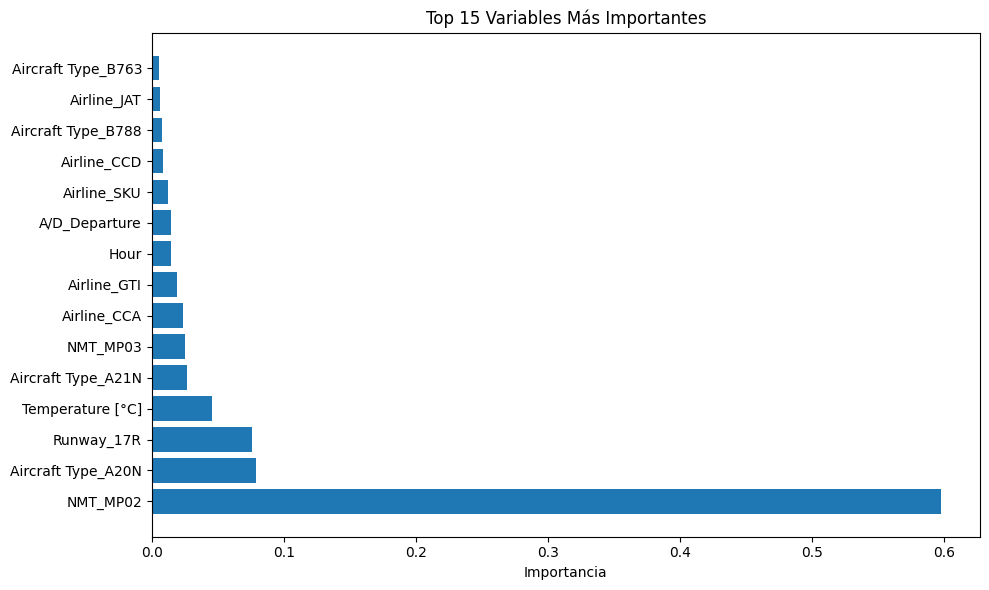

In [ ]:
# ======================
# ANÁLISIS DE RUIDO AERONÁUTICO
# Modelo Random Forest Unificado
# ======================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================
# 1. CONFIGURACIÓN INICIAL
# ======================
# Elige tu variable target (cambiar si es necesario):
TARGET = "SEL"  # Opciones: "SEL" o "LASmax"

# Features a incluir (personalizable):
FEATURES = [
    'Temperature [°C]',
    'Hour',
    'NMT',
    'Aircraft Type',
    'Airline',
    'Runway',
    'A/D',
    'is_night'  # Se creará automáticamente
]

# ======================
# 2. PREPROCESAMIENTO
# ======================
def preprocess_data(df):
    """Prepara los datos para el modelo"""
    # Crear variable temporal
    rdf['is_night'] = ((rdf['Hour'] >= 22) | (rdf['Hour'] < 6)).astype(int)

    # Seleccionar columnas relevantes
    df_model = rdf[FEATURES + [TARGET]].copy()

    # Codificar variables categóricas (OneHot para Random Forest)
    categorical_cols = ['Aircraft Type', 'NMT', 'A/D', 'Runway', 'Airline']
    df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

    return df_model

# Cargar datos (¡CAMBIAR por tu DataFrame!)
# df = pd.read_csv('tus_datos.csv')
df_model = preprocess_data(rdf)  # Aplicar preprocesamiento

# ======================
# 3. MODELADO
# ======================
X = df_model.drop(TARGET, axis=1)
y = df_model[TARGET]

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar modelo
model = RandomForestRegressor(
    n_estimators=150,  # Aumentar para mejor precisión
    max_depth=12,      # Controlar sobreajuste
    min_samples_split=5,
    n_jobs=-1,         # Usar todos los núcleos
    random_state=42
)
model.fit(X_train, y_train)

# ======================
# 4. EVALUACIÓN
# ======================
y_pred = model.predict(X_test)

print("\n" + "="*40)
print(f"RESULTADOS PARA {TARGET}:")
print("="*40)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} dB")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f} dB²")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} dB")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print("="*40 + "\n")

# ======================
# 5. ANÁLISIS ADICIONAL
# ======================
# Importancia de variables
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE VARIABLES:")
print(importances.head(10))

# Gráfico de importancia (opcional)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][:15], importances['Importance'][:15])
plt.title('Top 15 Variables Más Importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}
m
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3)
grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}



RESULTADOS PARA SEL:
MAE: 2.22 dB
MSE: 10.46 dB²
RMSE: 3.23 dB
R²: 0.6787

IMPORTANCIA DE VARIABLES:
                Feature  Importance
121            NMT_MP02    0.558130
124          Runway_17R    0.075780
6    Aircraft Type_A20N    0.073991
0      Temperature [°C]    0.067414
122            NMT_MP03    0.029019
7    Aircraft Type_A21N    0.025262
1                  Hour    0.025216
150         Airline_CCA    0.022512
185         Airline_GTI    0.018215
123       A/D_Departure    0.014082


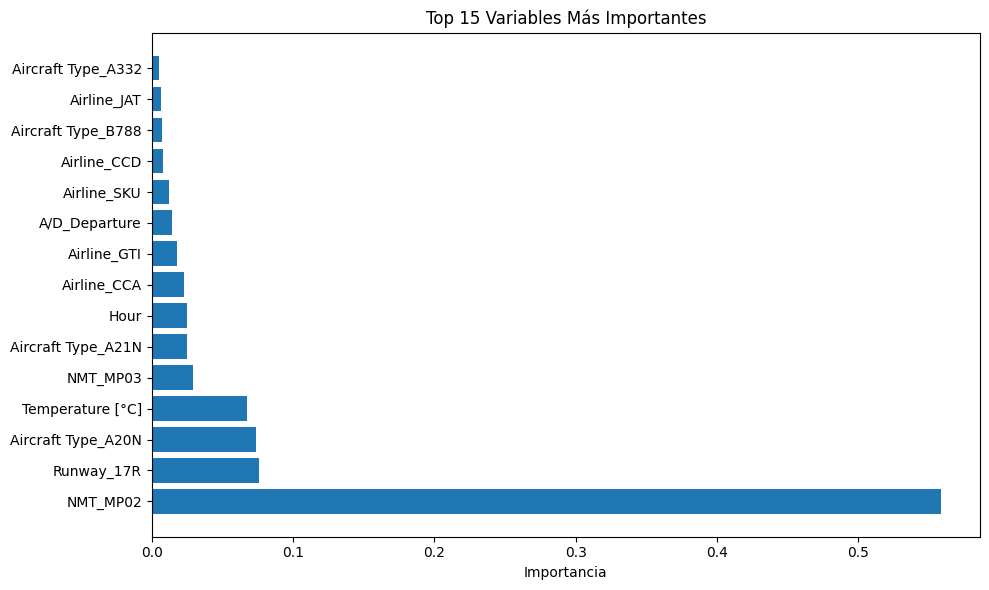

In [ ]:
# ======================
# 1. CONFIGURACIÓN INICIAL
# ======================
# Elige tu variable target (cambiar si es necesario):
TARGET = "SEL"  # Opciones: "SEL" o "LASmax"

# Features a incluir (personalizable):
FEATURES = [
    'Temperature [°C]',
    'Hour',
    'NMT',
    'Aircraft Type',
    'Airline',
    'Runway',
    'A/D',
    'is_night'  # Se creará automáticamente
]

# ======================
# 2. PREPROCESAMIENTO
# ======================
def preprocess_data(df):
    """Prepara los datos para el modelo"""
    # Crear variable temporal
    rdf['is_night'] = ((rdf['Hour'] >= 22) | (rdf['Hour'] < 6)).astype(int)

    # Seleccionar columnas relevantes
    df_model = rdf[FEATURES + [TARGET]].copy()

    # Codificar variables categóricas (OneHot para Random Forest)
    categorical_cols = ['Aircraft Type', 'NMT', 'A/D', 'Runway', 'Airline']
    df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

    return df_model

# Cargar datos (¡CAMBIAR por tu DataFrame!)
# df = pd.read_csv('tus_datos.csv')
df_model = preprocess_data(rdf)  # Aplicar preprocesamiento

# ======================
# 3. MODELADO
# ======================
X = df_model.drop(TARGET, axis=1)
y = df_model[TARGET]

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar modelo
model = RandomForestRegressor(
    n_estimators=200,  # Aumentar para mejor precisión
    max_depth=15,      # Controlar sobreajuste
    min_samples_split=5,
    n_jobs=-1,         # Usar todos los núcleos
    random_state=42
)
model.fit(X_train, y_train)

# ======================
# 4. EVALUACIÓN
# ======================
y_pred = model.predict(X_test)

print("\n" + "="*40)
print(f"RESULTADOS PARA {TARGET}:")
print("="*40)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} dB")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f} dB²")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} dB")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print("="*40 + "\n")

# ======================
# 5. ANÁLISIS ADICIONAL
# ======================
# Importancia de variables
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE VARIABLES:")
print(importances.head(10))

# Gráfico de importancia (opcional)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][:15], importances['Importance'][:15])
plt.title('Top 15 Variables Más Importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: guardar modelo

import joblib

joblib.dump(model, 'modelo_entrenado.pkl')


['modelo_entrenado.pkl']